# Statistical analysis of scooter rental service data

The GoFast service has data about users, their trips and subscriptions. The purpose of the research is to test hypotheses that will help the business grow.

For this it is planned:

• study user profiles:  
– total number of clients,  
– breakdown by age,  
– share of subscribers and one-time tenants;

• analyze the geography of trips:  
– frequency of occurrence of cities,  
– the most popular routes;

• compare the behavior of subscribers and one-time tenants:  
– number and duration of trips,  
– average distance;

• combine data about users, trips and subscriptions into a single dataframe;

• calculate revenue for each trip and monthly revenue per user.

Based on these calculations, key hypotheses will be tested:
1. Subscribers travel more often and bring more revenue to the service.
2. The average travel distance of subscribers does not exceed 3130 meters.
3. The monthly revenue of subscribers is greater than the monthly revenue of users without a subscription.

There are also two applied problems to be solved:

• Promotion with promo codes for a free month of subscription  
  – according to historical data, 10% of customers renew their subscription after the trial period;  
  – you need to determine the minimum number of promotional codes in order to receive at least 100 renewals with a 95% probability;  
  – model the distribution of the number of renewals, build a graph and give an answer based on the number of codes.  

• Push notification distribution analysis  
  – we estimate the open rate at 40% of those received;  
  – when sending 1 million messages using the normal approximation, you need to estimate the probability that the number of opens will not exceed 399.5 thousand;  
  – build a distribution graph and formulate a conclusion on risks.

## Step 1 Download data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
from scipy.stats import binom

In [2]:
users = pd.read_csv('/datasets/users_go.csv')
rides = pd.read_csv('/datasets/rides_go.csv')
subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')
# read all files


In [3]:
users.head(10)
# display the first 10 rows of the users table, which contains information about users


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


In [4]:
rides.head(10)
# display the first 10 rows of the rides table, which contains information about rides


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


In [5]:
subscriptions.head()
# display the subscriptions table, which contains information about subscriptions


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [6]:
users.info()
# Let's examine the information about the users table


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [7]:
rides.info()
# studying information about the rides table


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [8]:
subscriptions.info()
# studying information about the subscriptions table


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


**Conclusion:** While studying general information about the datasets, I found out that there are no gaps in them, but some columns need to change the data type (for example, the date column)

## Step 2 Data preprocessing

In [9]:
rides.dtypes 
# Let's study the data types in the columns of the rides table


user_id       int64
distance    float64
duration    float64
date         object
dtype: object

In [10]:
rides['date'] = pd.to_datetime(rides['date'])
# changing the data type in the date column of the rides table


Let's check the date range in the rides dataframe

In [11]:
rides['date'].min() # find the minimum date value


Timestamp('2021-01-01 00:00:00')

In [12]:
rides['date'].max() # find the maximum date value


Timestamp('2021-12-30 00:00:00')

In [13]:
rides['month'] = rides['date'].dt.month
# create a new column with the month of the trip


Let's check the changes

In [14]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 705.9 KB


In [15]:
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In step 1 we made sure that the dataframes do not have missing values, let's check them for duplicates.
Let's start with the users table

In [16]:
users.duplicated().sum()
# display the number of duplicate lines


31

In [17]:
users = users.drop_duplicates().reset_index(drop=True)
# remove 31 duplicates


In [18]:
users.duplicated().sum()
# check the number of duplicates after deletion


0

We will perform similar actions with the rides and subscriptions tables.

In [19]:
rides.duplicated().sum() # count the number of duplicates in the rides table


0

In [20]:
subscriptions.duplicated().sum()

0

As part of data preprocessing, we will check the 'distance' and 'duration' columns for anomalies, and also round their values ​​to 2 decimal places

In [21]:
rides['duration'] = rides['duration'].round(2) # round the values ​​in the duration column to 2 decimal places


In [22]:
rides['distance'] = rides['distance'].round(2) # round the values ​​in the distance column to 2 decimal places


In [23]:
f'({rides["duration"].min()}, {rides["duration"].max()})' # Let's check the range of values ​​in the duration column


'(0.5, 40.82)'

In [24]:
f'({rides["distance"].min()}, {rides["distance"].max()})' # Let's check the range of values ​​in the distance column


'(0.86, 7211.01)'

In both columns, the minimum values ​​are very close to zero, they can be considered anomalies, it is unlikely that the trip lasted 30 seconds, and the distance was 86 cm. However, these values ​​​​may mean that the user did not understand the application or the scooter was faulty, excluding these data will not be very good for the completeness of the picture. There are no "obvious" anomalies (such as negative time or distance).

**Output:** During data preprocessing, I changed the data type in the 'date' column of the 'rides' table from object to datetime. This made it easy to create a new column with the month of the trip, since the data covers one calendar year, one month number is enough to study the information. The 'distance' and 'duration' columns in the 'rides' table were rounded and checked for anomalies. Also, 31 duplicates were removed from the 'users' table; there were no duplicates in the other tables. All dataframes have no gaps.

## Step 3 Exploratory data analysis

#### Frequency of occurrence of cities

Let's build a bar chart of the distribution of the number of users by city, using the 'city' column in the 'users' table

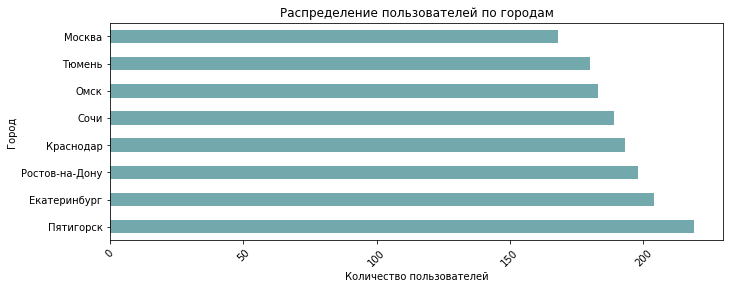

In [25]:
city_counts = users['city'].value_counts()
plt.figure(figsize=(12, 6))
city_counts.plot(kind='barh', figsize=(11, 4), color='#73A9AD')
plt.title("Distribution of users by city")
plt.xlabel("Number of users")
plt.ylabel("City")
plt.xticks(rotation=45)
plt.show()

The bar chart shows that in each city there are at least 150 users, there are no cities that stand out in terms of number, but the most users are from Pyatigorsk, the least from Moscow.

#### Ratio of users with subscription and without subscription

Let's build a bar chart of the distribution of users by subscription using the 'subscription_type' column ('free' - no subscription, 'ultra' - subscription)

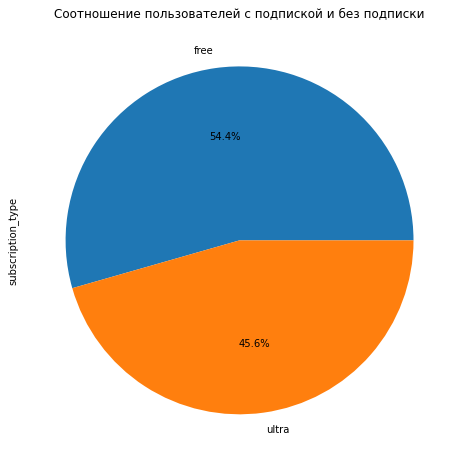

In [26]:
counts = users['subscription_type'].value_counts().sort_index()
counts.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%')
plt.title('Ratio of users with subscription and without subscription')
plt.show()

The graph shows that there are more users without a subscription than users with a subscription. Let's calculate the percentage

In the users table, 54% of users are without a subscription, 46% of users are with an ultra subscription.

#### Users age

Let's build a histogram of the distribution of users by age

Text(0.5, 1.0, 'Распределение пользователей по возрасту')

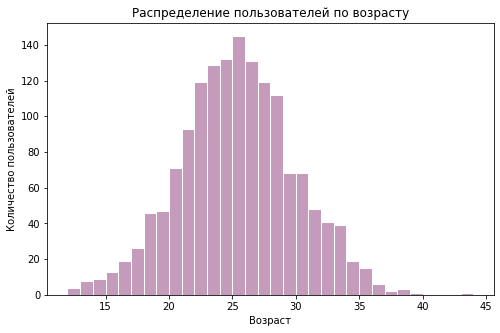

In [27]:
plt.figure(figsize=(8,5))
plt.hist(users['age'], bins=range(12, 45, 1), color='#C49BBB', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Number of users')
plt.title('Distribution of users by age')

In [28]:
users['age'].describe()
# describe the age column using the describe method


count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

The histogram shows that the service is used by people from 12 to 45 years old, the most common age among users is 25 years old. The results of the describe method show that 50% of users are between 22 and 28 years old. The age distribution is similar to a normal distribution.

#### Distance traveled by the user in one trip

Let's study the distance a user travels in one trip using a box-and-whisker graph.

<AxesSubplot:>

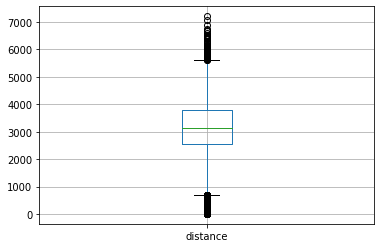

In [29]:
rides.boxplot('distance')

In [30]:
rides['distance'].describe()
# Let's describe the distance column using the describe method


count    18068.000000
mean      3070.659992
std       1116.831222
min          0.860000
25%       2543.227500
50%       3133.610000
75%       3776.220000
max       7211.010000
Name: distance, dtype: float64

The median distance for one trip is 3133 m, this can also be seen on the graph. 50% of trips have a distance from 2543 m to 3776 m. In the graph we see a large number of outliers, both less than the lower “whisker” and more than the upper “whisker”. The describe table shows that the minimum distance is less than 1 meter; this value is definitely an outlier, or indicates a malfunction of the rented scooter.

#### Duration of trips

We will also study the duration of trips using a boxplot graph.

<AxesSubplot:>

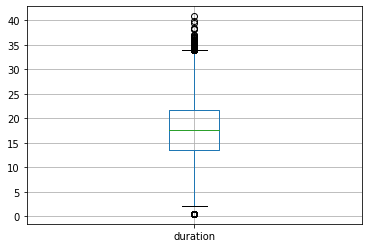

In [31]:
rides.boxplot('duration')

In [32]:
rides['duration'].describe()
# let's describe the duration column using describe


count    18068.000000
mean        17.805017
std          6.091071
min          0.500000
25%         13.600000
50%         17.680000
75%         21.722500
max         40.820000
Name: duration, dtype: float64

The median trip duration is 17.7 minutes. 50% of trips last from 13 to 21 minutes, but there are still outliers on the graph: the minimum value is 30 seconds, most likely this is the minimum trip in terms of distance, the maximum value is more than 40 minutes, which also agrees with the previous graph.

**Conclusion:** During the exploratory data analysis, I found out that:
   - most users are located in Pyatigorsk;
   - 54% of users do not have a subscription;
   - the most common age of users is from 22 to 28 years;
   - most trips had a distance of 2 to 4 km, and their duration was from 13 to 21 minutes.

## Step 4 Data merging

Let's combine the users, rides, subscriptions tables into one dataframe called 'data_all'

In [33]:
data_all = users.merge(rides, how='outer', on='user_id')
# join the users and rides tables using the 'user_id' column


In [34]:
data_all = data_all.merge(subscriptions, how='outer', on='subscription_type')
# join the data_all and subscriptions tables by the 'subscription_type' column


In [35]:
data_all
# display data_all on the screen for verification


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,25.60,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,15.82,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,6.23,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,18.51,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,26.27,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.10,19.82,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.42,21.41,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.19,18.44,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.31,16.67,2021-11-27,11,8,50,0


In [36]:
data_all.isna().sum() # check for gaps in the data_all table


user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [37]:
data_all.shape # display the dimension of the resulting dataframe


(18068, 12)

In [38]:
data_subscription_free = data_all[data_all['subscription_type'] == 'free']
# create a dataframe with users who do not have a subscription


In [39]:
data_subscription_ultra = data_all[data_all['subscription_type'] == 'ultra']
# create a dataframe with users who have a subscription


<AxesSubplot:>

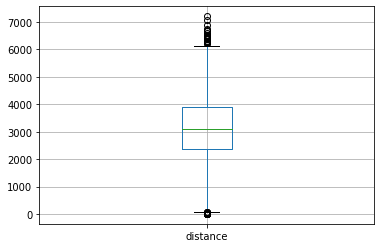

In [40]:
data_subscription_free.boxplot('distance')
# Let's build a boxplot graph for the 'distance' column in the data_subscription_free dataframe


<AxesSubplot:>

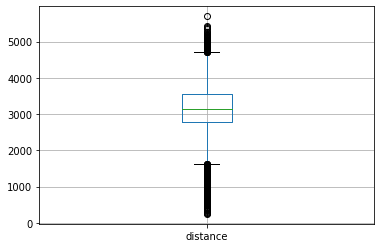

In [41]:
data_subscription_ultra.boxplot('distance')
# Let's build a boxplot for the 'distance' column in the data_subscription_ultra dataframe


The graphs show that the median in both cases is approximately at the same level. For trips with a subscription, the interquartile range is smaller than for trips without a subscription; the maximum values ​​(emissions) in their case reach more than 5000 meters, when for trips without a subscription the maximum value reaches 7000 meters. The second graph (for data_subscription_ultra) has fewer outliers.
Let's build histograms for the same characteristics

<AxesSubplot:>

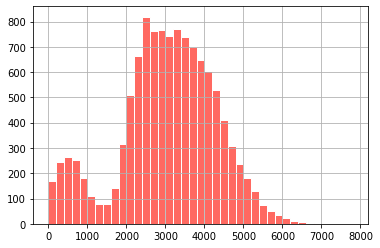

In [42]:
data_subscription_free['distance'].hist(bins=range(0, 8000, 200), edgecolor='white', color='#FF6961')
# Let's build a histogram for the 'distance' column in the 'data_subscription_free' dataframe


<AxesSubplot:>

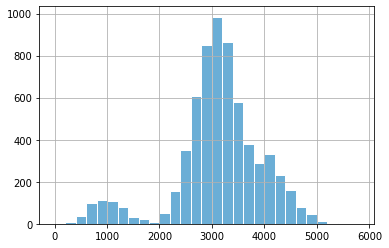

In [43]:
data_subscription_ultra['distance'].hist(bins=range(0, 6000, 200), edgecolor='white', color='#6baed6')
# Let's build a histogram for the 'distance' column in the 'data_subscription_ultra' dataframe


Both histograms show 2 “peaks”: shorter and longer trips. The first histogram shows that users without a subscription make more short trips from 200 to 400 meters than users with a subscription. Also, more than 100 trips for users without a subscription are located about 0 meters, this may be due to the fact that the user did not fully understand the application or scooter and canceled the trip without using the service. As could be seen from the boxplot graph, users with a subscription have a smaller spread of distances.

<AxesSubplot:>

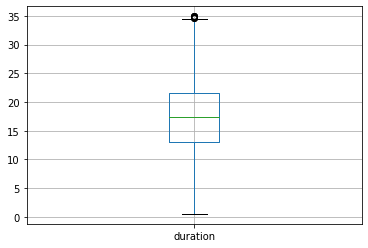

In [44]:
data_subscription_free.boxplot('duration')
# Let's build a boxplot for the 'duration' column in the 'data_subscription_free' table


<AxesSubplot:>

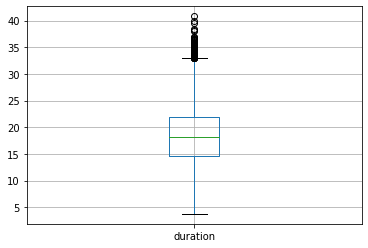

In [45]:
data_subscription_ultra.boxplot('duration')
# Let's build a boxplot for the 'duration' column in the 'data_subscription_ultra' table


In the case of travel duration, the situation is the same: the median of both dataframes is at the same level, but the interquarter range for users without subscriptions is wider. In the second graph (for users with a subscription) there are more outliers and they reach over 40 minutes, while in the first graph the maximum value reaches only 35 minutes.
Let's build distribution histograms for these columns in both dataframes

<AxesSubplot:>

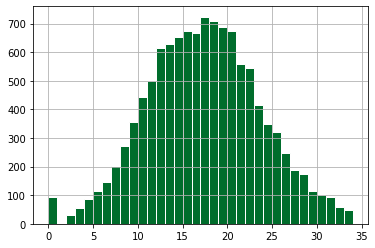

In [46]:
data_subscription_free['duration'].hist(bins=range(0, 35, 1), edgecolor='white', color='#006d2c')
# Let's build a distribution histogram for the 'duration' column in the 'data_subscription_free' table


<AxesSubplot:>

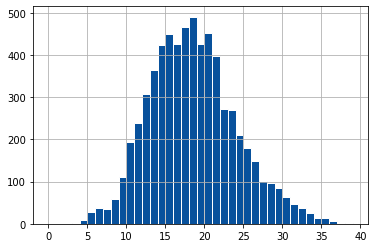

In [47]:
data_subscription_ultra['duration'].hist(bins=range(0, 40, 1), edgecolor='white', color='#08519c')
# Let's build a distribution histogram for the 'duration' column in the 'data_subscription_ultra' table


The first histogram shows that about 100 rides lasted 0 minutes, this could also be due to the fact that some users were unable to understand the application, or the scooter was faulty. In general, as in the case of travel distance, the graph of users with a subscription has a narrower “peak”

**Conclusion:** I combined data from three tables users, rides, subscriptions into one dataframe data_all, from which the dataframes data_subscription_free (dataframe with data about users without a subscription) and data_subscription_ultra (dataframe with data about users with a subscription) were created. For these dataframes, I visualized the distance and duration columns in two ways: using a boxplot and a histogram, and then compared the results of the resulting graphs. It turned out that trips with a subscription have a smaller interquartile range for the distance and duration of one trip. This may be due to the fact that subscription trips are made by the same users who travel the same distance (for example, to work or the gym). In the case of trips without a subscription, the peak is higher with short trips of 200-400 meters and there is a proportion of trips whose duration and distance are equal to or close to 0, this may be due to the fact that new users did not understand the application or the scooter was faulty.

## Step 5 Revenue calculation

In [48]:
agg_data = (data_all
    .groupby(['user_id','month', 'subscription_type'])
    .agg(distance_sum=('distance','sum'),
         duration_sum=('duration','sum'),
         trips_count=('distance','count'))
    .reset_index(level=['month','subscription_type'])
            )
# create a dataframe containing the total distance and duration, as well as the number of trips for one user for each month, using the reset_index method we leave only user_id in the index


In [49]:
agg_data['duration_sum'] = np.ceil(agg_data['duration_sum'])
# round the total duration up to a larger number


In [50]:
agg_data['revenue'] = np.where(
    agg_data['subscription_type'] == 'free',
    50 * agg_data['trips_count'] + 8 * agg_data['duration_sum'],
    199 + 6 * agg_data['duration_sum'])
# Let's calculate the revenue for each user by month


In [51]:
agg_data

,month,subscription_type,distance_sum,duration_sum,trips_count,revenue
user_id,,,,,,
1,1,ultra,7027.51,42.0,2,451.0
1,4,ultra,754.16,7.0,1,241.0
1,8,ultra,6723.47,45.0,2,469.0
1,10,ultra,5809.91,32.0,2,391.0
1,11,ultra,7003.50,54.0,3,523.0
...,...,...,...,...,...,...
1534,6,free,3409.47,25.0,2,300.0
1534,8,free,7622.45,48.0,2,484.0
1534,9,free,4928.17,23.0,1,234.0


**Conclusion:** I calculated the revenue for each user by month.

## Step 6 Hypothesis testing

#### Hypothesis about the equality of the average duration of trips for users with and without subscription

In [52]:
np.mean(data_subscription_free['duration'])
# Let's calculate the average trip duration for users without a subscription


17.390899896265562

In [53]:
np.mean(data_subscription_ultra['duration'])
# Let's calculate the average trip duration for users with a subscription


18.542016923076922

Let's formulate hypotheses:
H0 - the average travel durations of users with a subscription and without a subscription are equal
H1 - the average duration of trips of users with a subscription is longer

In [54]:
alpha = 0.05
# let's denote the significance level at 5%


In [55]:
results = st.ttest_ind(
    data_subscription_free['duration'],
    data_subscription_ultra['duration'],
    alternative='less')
# conduct a t-test to test the hypothesis


In [56]:
f'p-value: {results.pvalue:}'
# output p-value


'Значение p-value: 1.274138957151199e-34'

In [57]:
if results.pvalue < alpha:
    print('Rejecting the null hypothesis')
else:
    print('Cannot reject the null hypothesis')

Отвергаем нулевую гипотезу


**Conclusion:** The pvalue is very small, this means that we reject the hypothesis that the average travel durations of users without a subscription and with a subscription are equal, which means we accept the alternative hypothesis that the duration of trips of users with a subscription is longer.

#### Hypothesis about the equality of the average travel distance of users with a subscription to the optimal distance

In [58]:
np.mean(data_subscription_ultra['distance'])
# Let's calculate the average travel distance for users with a subscription


3115.445430769231

In [59]:
optimal_distance = 3130
# let's set the optimal distance from the point of view of scooter wear


Let's formulate hypotheses:
H0 - average travel distance is 3130 meters;
H1 - average travel distance is more than 3130 meters

In [60]:
alpha = 0.05
# set the significance level


In [61]:
results = st.ttest_1samp(
    data_subscription_ultra['distance'],
    optimal_distance,
    alternative='greater'
)
# conduct a t-test to test the hypothesis


In [62]:
f'p-value: {results.pvalue:.5f}'
# print the p-value


'Значение p-value: 0.91954'

In [63]:
if results.pvalue < alpha:
    print('Rejecting the null hypothesis')
else:
    print('Failed to reject the null hypothesis')

Не получилось отвергнуть нулевую гипотезу


**Conclusion:** We failed to reject the null hypothesis that the mean value of the trip distance is 3130, but since we were testing a one-sided hypothesis, this means that the distance could be less than 3130 meters. In other words, we can conclude that the average travel distance of users with a subscription does not exceed 3130 meters, which is optimal from the point of view of scooter wear.

#### Hypothesis about equality of revenue from users with and without subscription

In [64]:
np.mean(agg_data.query('subscription_type == "free"')['revenue'])
# Let's calculate the average monthly revenue from users without a subscription


325.79817593409825

In [65]:
np.mean(agg_data.query('subscription_type == "ultra"')['revenue'])
# Let's calculate the average monthly revenue from users with a subscription


361.44209133024486

Let's formulate hypotheses:
H0 - the average monthly revenue from users without a subscription is equal to the average monthly revenue from users with a subscription;
H1 - average monthly revenue from users without a subscription is less than average monthly revenue from users with a subscription

In [66]:
alpha = 0.05
# let's denote the level of significance


In [67]:
results = st.ttest_ind(
    agg_data.query('subscription_type == "free"')['revenue'],
    agg_data.query('subscription_type == "ultra"')['revenue'],
    alternative='less'
)
# testing the hypothesis using a t-test


In [68]:
f'p-value: {results.pvalue:}'
# print p-value


'Значение p-value: 2.743416414547796e-35'

In [69]:
if results.pvalue < alpha:
    print('Rejecting the null hypothesis')
else:
    print('Failed to reject the null hypothesis')

Отвергаем нулевую гипотезу


**Conclusion:** We reject the null hypothesis that the average monthly revenue for both groups of users is equal, which means we accept the alternative hypothesis that the average monthly revenue for users without a subscription is less than the average revenue for users with a subscription. It seems that users with a subscription actually benefit from the service.

#### Imagine this situation: the service’s technical team updated the servers with which the mobile application interacts. She hopes that because of this, the number of calls to technical support has decreased significantly. A certain file contains data for each user on the number of hits before and after the update. What test would you need to test this hypothesis?

We would need a two-sample t-test for dependent choices, since in this case we are studying the population before and after some change.
This was calculated using the code: st.ttest_rel(1sample, 2sample), where 1sample is a sample from the data before the change, 2sample is a sample from the data after the change.

## Step 7 Distributions

#### Promotion with distribution of promotional codes

When distributing a promotional code, we have 2 outcomes: the user will renew the subscription and the user will not renew the subscription - this is a Bernoulli experiment. Since we have n users, we have a binomial experiment in which we know p = 0.1 (probability of success), k = 100 (planned minimum number of users who renew their subscription) and alpha = 0.05 (probability of not fulfilling the plan). Knowing these parameters, we need to find the minimum value of n to satisfy the conditions

In [70]:
p = 0.1 # probability of subscription renewal
k = 100 # planned minimum number of users renewing their subscription
alpha = 0.05 # probability of not fulfilling the plan


Let's create a function to find the minimum value n find_min_n, which will take the parameters known to us: p, k, alpha and another parameter max_n - the maximum range of research, by default we will take max_n with a margin of 10000.
In the body of the function we will consider the probability of obtaining the value k-1 or less, since by condition the value equal to k satisfies the condition.

In [71]:
def find_min_n(p, k, alpha, max_n=10000):
    for n in range(k, max_n + 1): # consider n in the range from k to max_n + 1
        if binom.cdf(k-1, n, p) <= alpha:  # if the probability of getting a value is less than or equal to k-1 less than or equal to alpha, return n
            return n
    return 'n not found'
     # if n is not found in the range from k to max_n + 1, you need to set a larger max_n value


In [72]:
find_min_n(p, k, alpha) # let's find the minimum n for our parameters


1161

The minimum number of promotional codes that need to be distributed to users so that the probability of getting less than 100 subscribers is no more than 5% is 1161.

/opt/conda/lib/python3.9/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)


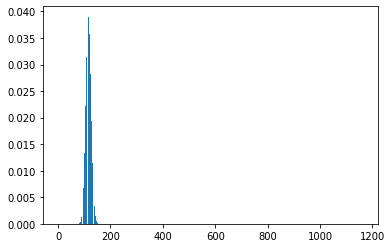

In [73]:
n = 1161 # number of attempts
p = 0.1 # probability of success

distr = []

for i in range(0, n + 1):
    current_value = binom.pmf(i, n, p)
    distr.append(current_value)

plt.bar(range(0, n + 1), distr)
plt.show() # construct a binomial distribution


**Conclusion:** The minimum number of promotional codes to complete the plan is 1161. The distribution of the binomial experiment turned out to be skewed to the right, which is typical for a small parameter p = 0.1. The graph shows that the probability of getting less than 99 successes is really small, just as the probability of getting values ​​greater than 200 successes is small.

#### Push notifications

In [74]:
p = 0.4 # the likelihood that a push notification will be opened
n = 1000000 # number of notifications


In [75]:
mu = n*p # let's set checkmate. expectation of a normal distribution equal to mat. expecting a binomial distribution
sigma = (n * p * (1 - p))**(1/2) # let's set the standard deviation of the normal distribution equal to the standard deviation of the binomial distribution


In [76]:
# checking the approximation condition
if (mu - (3 * sigma) >= 0) and ((mu + (3 * sigma) <= n)):
    print('The condition is met')
else:
    print('Condition not met')

Условие выполняется


In [77]:
distr = st.norm(mu, sigma) # we set a normal distribution with the resulting parameters


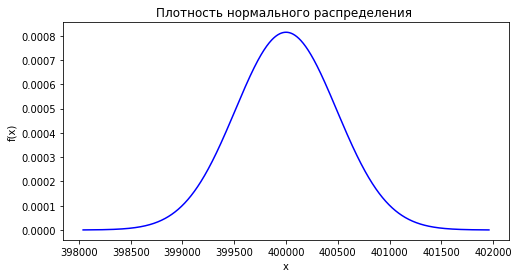

In [78]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = distr.pdf(x)
plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f'N({mu}, {sigma}²)', color='blue')
plt.title('Normal distribution density')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

In [79]:
distr.cdf(399500) # find the probability that notifications will be opened by no more than 399500 users


0.15371708296369768

**Conclusion:** With the parameters n and p of the binomial experiment, it was possible to approximate the normal distribution and use it to find the probability that no more than 399.5 thousand users will open notifications; it turned out to be 15.37%

## General conclusion

During the project work:
   - I studied data on users, trips and types of subscriptions of the GoFast scooter rental service;
   - did preprocessing of the data: changed the data type in the date column of the rides table to datetime, using which I created a new column with the number of the month of the trip, deleted 31 duplicates in the users table;
   - conducted a research analysis of the frequency of occurrence of cities: the most frequently encountered city is Pyatigorsk, the least frequent is Moscow;
   - conducted a research analysis of the age of users, which covers from 12 to 45 years, the most common group of users is from 22 to 28 years;
   - conducted a research analysis of the distance that users travel per trip and the duration of the trip, the most popular values were from 2 to 4 km for 13 to 21 minutes
   - created the following dataframes: data_all (a union of three tables users, rides, subscriptions), data_subscription_free (dataframe with information about trips of users without a subscription), data_subscription_ultra (dataframe with information about trips of users with a subscription)
   - visualized and compared the distance of 1 trip and the duration of the trip for users without a subscription and users with a subscription according to data from the data_subscription_free and data_subscription_ultra tables
   - created a dataframe agg_data, which contains information about the total duration of trips, total distance and number of trips for each user for each month, using this dataframe to calculate the revenue that each user brought in each month of using the rental;
   - rejected the hypothesis that the average duration of trips of users without a subscription and with a subscription are equal, based on this, accepted the alternative hypothesis that the duration of trips of users with a subscription is longer;
   - it was not possible to reject the hypothesis that the average distance of 1 trip of users with a subscription is less than or equal to 3130 meters (the optimal distance in terms of scooter wear)
   - rejected the hypothesis that the average monthly revenue per 1 user of users without a subscription and users with a subscription are equal, in favor of the hypothesis that the revenue of users with a subscription is higher;
   - determined the necessary test to check the effectiveness of server updates - a two-sample t-test for dependent samples (calls to technical support before and after the update);
   - determined the minimum value for sending promotional codes for a free month of subscription, provided that the probability that less than 100 people will renew their subscription is 5%, this number is 1161 promotional codes; plotted the binomial distribution for this experiment;
   - approximated the binomial distribution as normal for sending push notifications, using this distribution I found the probability that out of 1 million users no more than 399.5 thousand people will open a push notification - 15.37%.
   
   
   Based on the hypotheses being tested, we can conclude that users with a subscription are actually more profitable for the company: they travel more kilometers and generate higher revenue than users without a subscription. This means that the marketing department should work on attracting more subscribers to the application.